Ray D'Inverno, *Introducing Einstein's Relativity* (Oxford University Press, 1992): Chapter 20.

## Setup

In [1]:
<< mTensor`

In [2]:
DefineKind[Alphabet["Greek"], Greek];
SetDefaultKind[Greek];
On[CoordinateBasisFlag[Greek]]

We assume that the metric differs only slightly from the Minkowski metric:
$$
  g_{\mu\nu} = \eta_{\mu\nu} + \epsilon h_{\mu\nu}.
$$

In [5]:
Tdefine[{\[Eta], h}, "2+"]

In [6]:
metricRule = {Metricg[a_, b_] :> \[Eta][a, b] + \[Epsilon] h[a, b]}

{Metricg[a_, b_] :> η[a, b] + ϵ h[a, b]}

Because the Minkowski metric is constant,
$$
  \partial_{\mu} \eta_{\nu\rho} = 0.
$$

In [7]:
etaRule = {BD[a_, \[Eta][b_, c_]] :> 0}

{BD[a_, η[b_, c_]] :> 0}

The ordinary derivative is a commuting operator:
$$
  \partial_\mu \partial_\nu T_{...}^{...}
  = \partial_\nu \partial_\mu T_{...}^{...}.
$$

In [8]:
bdRule = {BD[a_, BD[b_, expr_]] :> 
    BD[b, BD[a, expr]] /; !OrderedQ[{a, b}]}

{BD[a_, BD[b_, expr_]] :> BD[b, BD[a, expr]] /; !OrderedQ[{a, b}]}

In [9]:
SetAttributes[\[Epsilon], Constant] (* for BD[_, \[Epsilon]] = 0 *)

We shall neglect terms of second order or higher in $\epsilon$, and raise and lower indices with $\eta_{\mu\nu}$.

## Connection

-(BD[lα, Metricg[lμ, lν]] Metricg[uρ, uα])   BD[lμ, Metricg[lν, lα]] Metricg[uρ, uα]
------------------------------------------ + --------------------------------------- + 
                    2                                           2
 
    BD[lν, Metricg[lμ, lα]] Metricg[uρ, uα]
>   ---------------------------------------
                       2
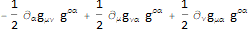

In [10]:
affine = GammaCD[l\[Mu], l\[Nu], u\[Rho]] // GammaToMetric

2                                 2
-(ϵ  BD[lα, h[lμ, lν]] h[uρ, uα])   ϵ  BD[lμ, h[lν, lα]] h[uρ, uα]
--------------------------------- + ------------------------------ + 
                2                                 2
 
     2
    ϵ  BD[lν, h[lμ, lα]] h[uρ, uα]   ϵ BD[lα, h[lμ, lν]] η[uρ, uα]
>   ------------------------------ - ----------------------------- + 
                  2                                2
 
    ϵ BD[lμ, h[lν, lα]] η[uρ, uα]   ϵ BD[lν, h[lμ, lα]] η[uρ, uα]
>   ----------------------------- + -----------------------------
                  2                               2
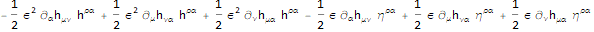

In [11]:
affine /. metricRule /. etaRule

-(ϵ BD[lα, h[lμ, lν]] η[uρ, uα])   ϵ BD[lμ, h[lν, lα]] η[uρ, uα]
-------------------------------- + ----------------------------- + 
               2                                 2
 
    ϵ BD[lν, h[lμ, lα]] η[uρ, uα]
>   -----------------------------
                  2
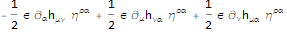

In [12]:
Normal[Series[%, {\[Epsilon], 0, 1}]]

ϵ BD[lμ, h[lν, uρ]]   ϵ BD[lν, h[lμ, uρ]]   ϵ BD[uρ, h[lμ, lν]]
------------------- + ------------------- - -------------------
         2                     2                     2
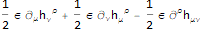

In [13]:
affine = Absorb[%, \[Eta], CovDs -> {BD}]

GammaCD[lμ_, lν_, uρ_] :> 
 
             ϵ BD[lμ, h[lν, uρ]]   ϵ BD[lν, h[lμ, uρ]]   ϵ BD[uρ, h[lμ, lν]]
>   DumFresh[------------------- + ------------------- - -------------------]
                      2                     2                     2
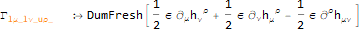

In [14]:
affineRule = RuleUnique[GammaCD[l\[Mu]_, l\[Nu]_, u\[Rho]_], affine]

Formula:
$$
  \Gamma_{\mu\nu}^{\ \ \ \ \ \rho}
  \Rightarrow \frac{\epsilon}{2} (\partial_\mu h_\nu^{\ \ \rho}
  + \partial_\nu h_\mu^{\ \ \rho}
  - \partial^\rho h_{\mu\nu})
$$

ϵ BD[lμ, h[lν, uρ]]   ϵ BD[lν, h[lμ, uρ]]   ϵ BD[uρ, h[lμ, lν]]
------------------- + ------------------- - -------------------
         2                     2                     2
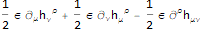

In [15]:
GammaCD[l\[Mu], l\[Nu], u\[Rho]] /. affineRule

## Curvature

In [16]:
RiemannCD[l\[Mu], l\[Nu], l\[Rho], l\[Sigma]] // RiemannToGamma

GammaCD[lμ, lρ, uα] GammaCD[lν, lα, lσ] - GammaCD[lμ, lα, lσ] GammaCD[lν, lρ, uα] - 
 
>   BD[lμ, GammaCD[lν, lρ, uα]] Metricg[lσ, lα] + 
 
>   BD[lν, GammaCD[lμ, lρ, uα]] Metricg[lσ, lα]

-(ϵ BD[lμ, BD[lν, h[lρ, uα]]] η[lσ, lα])   ϵ BD[lμ, BD[lρ, h[lν, uα]]] η[lσ, lα]
---------------------------------------- - ------------------------------------- + 
                   2                                         2
 
    ϵ BD[lμ, BD[uα, h[lν, lρ]]] η[lσ, lα]   ϵ BD[lν, BD[lμ, h[lρ, uα]]] η[lσ, lα]
>   ------------------------------------- + ------------------------------------- + 
                      2                                       2
 
    ϵ BD[lν, BD[lρ, h[lμ, uα]]] η[lσ, lα]   ϵ BD[lν, BD[uα, h[lμ, lρ]]] η[lσ, lα]
>   ------------------------------------- - -------------------------------------
                      2                                       2
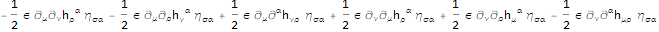

In [17]:
Normal[Series[% //. 
   Join[metricRule, {affineRule}, etaRule], {\[Epsilon], 0, 1}]]

-(ϵ BD[lμ, BD[lρ, h[lν, lσ]]])   ϵ BD[lμ, BD[lσ, h[lν, lρ]]]
------------------------------ + --------------------------- + 
              2                               2
 
    ϵ BD[lν, BD[lρ, h[lμ, lσ]]]   ϵ BD[lν, BD[lσ, h[lμ, lρ]]]
>   --------------------------- - ---------------------------
                 2                             2
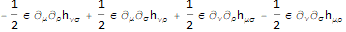

In [18]:
riemann = Absorb[%, \[Eta], CovDs -> {BD}] // TindexSort

RiemannCD[lμ_, lν_, lρ_, lσ_] :> 
 
             -(ϵ BD[lμ, BD[lρ, h[lν, lσ]]])   ϵ BD[lμ, BD[lσ, h[lν, lρ]]]
>   DumFresh[------------------------------ + --------------------------- + 
                           2                               2
 
      ϵ BD[lν, BD[lρ, h[lμ, lσ]]]   ϵ BD[lν, BD[lσ, h[lμ, lρ]]]
>     --------------------------- - ---------------------------]
                   2                             2
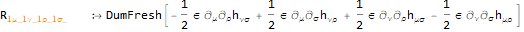

In [19]:
curvRule = 
  RuleUnique[RiemannCD[l\[Mu]_, l\[Nu]_, l\[Rho]_, l\[Sigma]_], 
   riemann]

Riemann curvature:
$$
  R_{\mu\nu\rho\sigma} \Rightarrow -\frac{\epsilon}{2} \left[
  \partial_\mu \partial_\rho h_{\nu\sigma}
  - \partial_\mu \partial_\sigma h_{\nu\rho}
  - (\mu \leftrightarrow \nu) \right]
$$

-(ϵ BD[lμ, BD[lρ, h[lν, lσ]]])   ϵ BD[lμ, BD[lσ, h[lν, lρ]]]
------------------------------ + --------------------------- + 
              2                               2
 
    ϵ BD[lν, BD[lρ, h[lμ, lσ]]]   ϵ BD[lν, BD[lσ, h[lμ, lρ]]]
>   --------------------------- - ---------------------------
                 2                             2
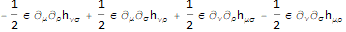

In [20]:
RiemannCD[l\[Mu], l\[Nu], l\[Rho], l\[Sigma]] /. curvRule

-(ϵ BD[lμ, BD[lρ, h[lν, lσ]]] η[uν, uσ])   ϵ BD[lμ, BD[lσ, h[lν, lρ]]] η[uν, uσ]
---------------------------------------- + ------------------------------------- + 
                   2                                         2
 
    ϵ BD[lν, BD[lρ, h[lμ, lσ]]] η[uν, uσ]   ϵ BD[lν, BD[lσ, h[lμ, lρ]]] η[uν, uσ]
>   ------------------------------------- - -------------------------------------
                      2                                       2
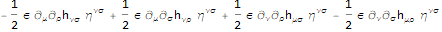

In [21]:
\[Eta][u\[Nu], u\[Sigma]] riemann

-(ϵ BD[lμ, BD[lρ, h[lν, uν]]])   ϵ BD[lμ, BD[uν, h[lν, lρ]]]
------------------------------ + --------------------------- + 
              2                               2
 
    ϵ BD[uσ, BD[lρ, h[lμ, lσ]]]   ϵ BD[uσ, BD[lσ, h[lμ, lρ]]]
>   --------------------------- - ---------------------------
                 2                             2
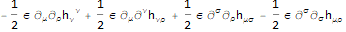

In [22]:
ricci = Absorb[%, \[Eta], CovDs -> {BD}]

Ricci tensor:
$$
  R_{\mu\nu} \Rightarrow -\frac{\epsilon}{2} \left[
  \partial^2 h_{\mu\nu}
  + \partial_\mu \partial_\nu h_{\rho}^{\ \ \rho}
  - \partial_\mu \partial^\rho h_{\nu\rho}
  - \partial_\nu \partial^\rho h_{\mu\rho}
  \right]
$$

-(ϵ BD[lμ, BD[lρ, h[lν, uν]]] η[uμ, uρ])   ϵ BD[lμ, BD[uν, h[lν, lρ]]] η[uμ, uρ]
---------------------------------------- + ------------------------------------- + 
                   2                                         2
 
    ϵ BD[uσ, BD[lρ, h[lμ, lσ]]] η[uμ, uρ]   ϵ BD[uσ, BD[lσ, h[lμ, lρ]]] η[uμ, uρ]
>   ------------------------------------- - -------------------------------------
                      2                                       2
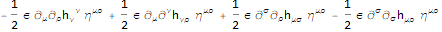

In [23]:
\[Eta][u\[Mu], u\[Rho]] ricci

In [24]:
scalar = Absorb[%, \[Eta], CovDs -> {BD}] // Dum

-(ϵ BD[uα, BD[lα, h[lβ, uβ]]]) + ϵ BD[uα, BD[uβ, h[lβ, lα]]]

Scalar curvature:
$$
  R \Rightarrow -\epsilon \left[
  \partial^2 h_\mu^{\ \ \mu}
  - \partial_\mu \partial_\nu h^{\mu\nu}
  \right]
$$

-(ϵ BD[lμ, BD[lρ, h[lν, uν]]])   ϵ BD[lμ, BD[uν, h[lν, lρ]]]
------------------------------ + --------------------------- + 
              2                               2
 
    ϵ BD[uσ, BD[lρ, h[lμ, lσ]]]   ϵ BD[uσ, BD[lσ, h[lμ, lρ]]]
>   --------------------------- - --------------------------- + 
                 2                             2
 
    ϵ BD[uα, BD[lα, h[lβ, uβ]]] Metricg[lμ, lρ]
>   ------------------------------------------- - 
                         2
 
    ϵ BD[uα, BD[uβ, h[lβ, lα]]] Metricg[lμ, lρ]
>   -------------------------------------------
                         2
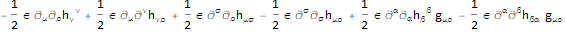

In [25]:
ricci - 1/2 Metricg[l\[Mu], l\[Rho]] scalar

-(ϵ BD[lμ, BD[lρ, h[lν, uν]]])   ϵ BD[lμ, BD[uν, h[lν, lρ]]]
------------------------------ + --------------------------- + 
              2                               2
 
    ϵ BD[uσ, BD[lρ, h[lμ, lσ]]]   ϵ BD[uσ, BD[lσ, h[lμ, lρ]]]
>   --------------------------- - --------------------------- + 
                 2                             2
 
    ϵ BD[uα, BD[lα, h[lβ, uβ]]] η[lμ, lρ]   ϵ BD[uα, BD[uβ, h[lβ, lα]]] η[lμ, lρ]
>   ------------------------------------- - -------------------------------------
                      2                                       2
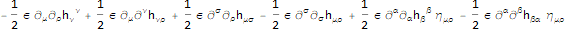

In [26]:
einstein = 
 Normal[Series[% //. Join[metricRule, etaRule], {\[Epsilon], 0, 1}]]

## Bianchi identities

$$
  \nabla_{[\mu} R_{\nu\rho]\alpha}^{\ \ \ \ \ \ \ \beta}
  = \partial_{[\mu} R_{\nu\rho]\alpha}^{\ \ \ \ \ \ \ \beta}
  = 0
$$

BD[lμ, RiemannCD[lν, lρ, lσ, lδ]]   BD[lμ, RiemannCD[lρ, lν, lσ, lδ]]
--------------------------------- - --------------------------------- - 
                6                                   6
 
    BD[lν, RiemannCD[lμ, lρ, lσ, lδ]]   BD[lν, RiemannCD[lρ, lμ, lσ, lδ]]
>   --------------------------------- + --------------------------------- + 
                    6                                   6
 
    BD[lρ, RiemannCD[lμ, lν, lσ, lδ]]   BD[lρ, RiemannCD[lν, lμ, lσ, lδ]]
>   --------------------------------- - ---------------------------------
                    6                                   6
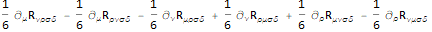

In [27]:
bianchi1 = 
 AntisymmetrizeIndices[{l\[Mu], l\[Nu], l\[Rho]}, 
  BD[l\[Mu], RiemannCD[l\[Nu], l\[Rho], l\[Sigma], l\[Delta]]]]

ϵ BD[lμ, BD[lν, BD[lδ, h[lρ, lσ]]]]   ϵ BD[lμ, BD[lν, BD[lσ, h[lρ, lδ]]]]
----------------------------------- - ----------------------------------- - 
                 6                                     6
 
    ϵ BD[lμ, BD[lρ, BD[lδ, h[lν, lσ]]]]   ϵ BD[lμ, BD[lρ, BD[lσ, h[lν, lδ]]]]
>   ----------------------------------- + ----------------------------------- - 
                     6                                     6
 
    ϵ BD[lν, BD[lμ, BD[lδ, h[lρ, lσ]]]]   ϵ BD[lν, BD[lμ, BD[lσ, h[lρ, lδ]]]]
>   ----------------------------------- + ----------------------------------- + 
                     6                                     6
 
    ϵ BD[lν, BD[lρ, BD[lδ, h[lμ, lσ]]]]   ϵ BD[lν, BD[lρ, BD[lσ, h[lμ, lδ]]]]
>   ----------------------------------- - ----------------------------------- + 
                     6                                     6
 
    ϵ BD[lρ, BD[lμ, BD[lδ, h[lν, lσ]]]]   ϵ BD[lρ, BD[lμ, BD[lσ, h[lν, lδ]]]]
>   ----------------------------------- - ----------------------------------- - 
                     6                                     6
 
    ϵ BD[lρ, BD[lν, BD[lδ, h[lμ, lσ]]]]   ϵ BD[lρ, BD[lν, BD[lσ, h[lμ, lδ]]]]
>   ----------------------------------- + -----------------------------------
                     6                                     6
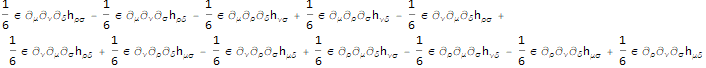

In [28]:
bianchi1 //. Join[{curvRule}, metricRule, etaRule]

In [29]:
% // TindexSort

0

## Gauge transformations

In [30]:
Tdefine[\[Xi], 1]

Under a coordinate transformation $x'^\mu = x^\mu + \epsilon \xi^\mu$, the metric transforms $h'_{\mu\nu} = h_{\mu\nu} - 2 \partial_{(\mu} \xi_{\nu)}$:

In [31]:
gaugeTr = {h[a_, b_] :> h[a, b] - BD[a, \[Xi][b]] - BD[b, \[Xi][a]]}

{h[a_, b_] :> h[a, b] - BD[a, ξ[b]] - BD[b, ξ[a]]}

Curvature tensor is invariant under the gauge transformation:

-(ϵ BD[lμ, BD[lρ, BD[lν, ξ[lσ]]]])   ϵ BD[lμ, BD[lρ, BD[lσ, ξ[lν]]]]
---------------------------------- - ------------------------------- + 
                2                                   2
 
    ϵ BD[lμ, BD[lσ, BD[lν, ξ[lρ]]]]   ϵ BD[lμ, BD[lσ, BD[lρ, ξ[lν]]]]
>   ------------------------------- + ------------------------------- + 
                   2                                 2
 
    ϵ BD[lν, BD[lρ, BD[lμ, ξ[lσ]]]]   ϵ BD[lν, BD[lρ, BD[lσ, ξ[lμ]]]]
>   ------------------------------- + ------------------------------- - 
                   2                                 2
 
    ϵ BD[lν, BD[lσ, BD[lμ, ξ[lρ]]]]   ϵ BD[lν, BD[lσ, BD[lρ, ξ[lμ]]]]
>   ------------------------------- - -------------------------------
                   2                                 2
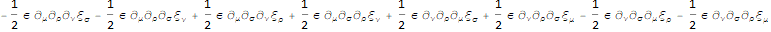

In [32]:
riemann - (riemann /. gaugeTr)

In [33]:
% // TindexSort

0

-(ϵ BD[lμ, BD[lρ, BD[lν, ξ[uν]]]])   ϵ BD[lμ, BD[lρ, BD[uν, ξ[lν]]]]
---------------------------------- - ------------------------------- + 
                2                                   2
 
    ϵ BD[lμ, BD[uν, BD[lν, ξ[lρ]]]]   ϵ BD[lμ, BD[uν, BD[lρ, ξ[lν]]]]
>   ------------------------------- + ------------------------------- + 
                   2                                 2
 
    ϵ BD[uσ, BD[lρ, BD[lμ, ξ[lσ]]]]   ϵ BD[uσ, BD[lρ, BD[lσ, ξ[lμ]]]]
>   ------------------------------- + ------------------------------- - 
                   2                                 2
 
    ϵ BD[uσ, BD[lσ, BD[lμ, ξ[lρ]]]]   ϵ BD[uσ, BD[lσ, BD[lρ, ξ[lμ]]]]
>   ------------------------------- - -------------------------------
                   2                                 2
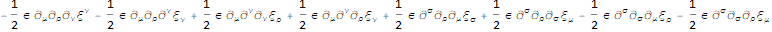

In [34]:
ricci - (ricci /. gaugeTr)

-(ϵ BD[lμ, BD[lρ, BD[lα, ξ[uα]]]])   ϵ BD[lμ, BD[lρ, BD[uα, ξ[lα]]]]
---------------------------------- + -------------------------------
                2                                   2
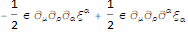

In [35]:
% // Tsimplify

In [36]:
DnUpPair[%, CovDs -> {BD}]

0

In [37]:
scalar - (scalar /. gaugeTr)

-(ϵ BD[uα, BD[lα, BD[lβ, ξ[uβ]]]]) - ϵ BD[uα, BD[lα, BD[uβ, ξ[lβ]]]] + 
 
>   ϵ BD[uα, BD[uβ, BD[lα, ξ[lβ]]]] + ϵ BD[uα, BD[uβ, BD[lβ, ξ[lα]]]]

In [38]:
% // Tsimplify

-(ϵ BD[uα, BD[lα, BD[lβ, ξ[uβ]]]]) + ϵ BD[uα, BD[uβ, BD[lβ, ξ[lα]]]]

In [39]:
% //. bdRule

-(ϵ BD[lα, BD[lβ, BD[uα, ξ[uβ]]]]) + ϵ BD[lβ, BD[uα, BD[uβ, ξ[lα]]]]

In [40]:
DnUpPair[%, CovDs -> {BD}]

-(ϵ BD[lα, BD[lβ, BD[uα, ξ[uβ]]]]) + ϵ BD[lβ, BD[lα, BD[uβ, ξ[uα]]]]

In [41]:
% // Tsimplify

0

Let $\psi_{\mu\nu} = h_{\mu\nu} - \frac{1}{2} \eta_{\mu\nu} h$, the trace-reverse of $h_{\mu\nu}$.

In [42]:
Tdefine[\[Psi], "2+"]

h[l%32, u%32] η[a, b]
{h[a_, b_] :> DumFresh[--------------------- + ψ[a, b]] /; DnIndexQ[a] && DnIndexQ[b], 
                                 2
 
>   ψ[a_, b_] :> DumFresh[-h[a, b]] /; PairIndexQ[a, b]}
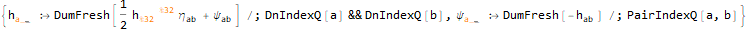

In [43]:
psiRule = {RuleUnique[
   h[a_, b_], \[Psi][a, b] + 1/2 \[Eta][a, b] h[l\[Rho], u\[Rho]], 
   DnIndexQ[a] && DnIndexQ[b]], 
  RuleUnique[\[Psi][a_, b_], -h[a, b], PairIndexQ[a, b]]}

Under the gauge transformation $\psi_{\mu\nu}$ transfoms as

BD[lρ, ξ[uρ]] η[lμ, lν]   BD[uρ, ξ[lρ]] η[lμ, lν]
-BD[lμ, ξ[lν]] - BD[lν, ξ[lμ]] + ----------------------- + ----------------------- + 
                                            2                         2
 
    h[lα, uα] η[lμ, lν]   h[lρ, uρ] η[lμ, lν]
>   ------------------- - ------------------- + ψ[lμ, lν]
             2                     2
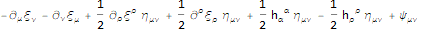

In [44]:
h[l\[Mu], l\[Nu]] - 
   1/2 \[Eta][l\[Mu], l\[Nu]] h[l\[Rho], 
     u\[Rho]] /. gaugeTr /. psiRule

h[lα, uα] η[lμ, lν]
-BD[lμ, ξ[lν]] - BD[lν, ξ[lμ]] + BD[lρ, ξ[uρ]] η[lμ, lν] + ------------------- - 
                                                                    2
 
    h[lρ, uρ] η[lμ, lν]
>   ------------------- + ψ[lμ, lν]
             2
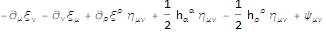

In [45]:
DnUpPair[%, CovDs -> {BD}]

In [46]:
% // Tsimplify

-BD[lμ, ξ[lν]] - BD[lν, ξ[lμ]] + BD[lα, ξ[uα]] η[lμ, lν] + ψ[lμ, lν]

from which we find $\partial_\mu \psi'^{\mu\nu} = \partial_\mu \psi^{\mu\nu} - \partial^2 \xi^\nu$. The gauge transformation therefore leads to the Einstein gauge $\partial_\mu \psi'^{\mu\nu} = 0$ if we choose $\xi^\mu$ to satisfy $\partial^2 \xi^\nu = \partial_\mu \psi^{\mu\nu}$.

The Einstein tensor becomes

-(ϵ BD[lμ, BD[lρ, h[lν, uν]]])   ϵ BD[lμ, BD[uν, ψ[lν, lρ]]]
------------------------------ + --------------------------- + 
              2                               2
 
    ϵ BD[uσ, BD[lρ, ψ[lμ, lσ]]]   ϵ BD[uσ, BD[lσ, ψ[lμ, lρ]]]
>   --------------------------- - --------------------------- + 
                 2                             2
 
    ϵ BD[uα, BD[lα, h[lβ, uβ]]] η[lμ, lρ]   ϵ BD[uα, BD[uβ, ψ[lβ, lα]]] η[lμ, lρ]
>   ------------------------------------- - ------------------------------------- - 
                      2                                       2
 
    ϵ BD[uσ, BD[lσ, h[lα, uα]]] η[lμ, lρ]
>   ------------------------------------- - 
                      4
 
    ϵ BD[uα, BD[uβ, h[lγ, uγ]]] η[lβ, lα] η[lμ, lρ]
>   ----------------------------------------------- + 
                           4
 
    ϵ BD[uσ, BD[lρ, h[lα, uα]]] η[lμ, lσ]   ϵ BD[lμ, BD[uν, h[lα, uα]]] η[lν, lρ]
>   ------------------------------------- + -------------------------------------
                      4                                       4
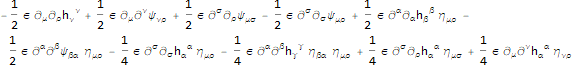

In [47]:
einstein /. psiRule /. etaRule

ϵ BD[lμ, BD[uα, ψ[lα, lρ]]]   ϵ BD[uα, BD[lα, ψ[lμ, lρ]]]
--------------------------- - --------------------------- + 
             2                             2
 
    ϵ BD[uα, BD[lρ, ψ[lμ, lα]]]   ϵ BD[lα, BD[uα, h[lβ, uβ]]] η[lμ, lρ]
>   --------------------------- - ------------------------------------- + 
                 2                                  4
 
    ϵ BD[uα, BD[lα, h[lβ, uβ]]] η[lμ, lρ]   ϵ BD[uα, BD[uβ, ψ[lβ, lα]]] η[lμ, lρ]
>   ------------------------------------- - -------------------------------------
                      4                                       2
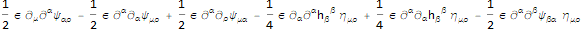

In [48]:
Absorb[%, \[Eta], CovDs -> {BD}] // Dum

ϵ BD[lα, BD[lρ, ψ[lμ, uα]]]   ϵ BD[lα, BD[uα, ψ[lμ, lρ]]]
--------------------------- - --------------------------- + 
             2                             2
 
    ϵ BD[lμ, BD[lα, ψ[uα, lρ]]]   ϵ BD[lα, BD[lβ, ψ[uβ, uα]]] η[lμ, lρ]
>   --------------------------- - -------------------------------------
                 2                                  2
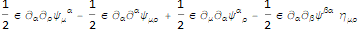

In [49]:
eq = DnUpPair[%, CovDs -> {BD}]

Therefore, if we choose the Einstein gauge $\partial_\mu \psi^{\mu\nu} = \partial_\mu h^{\mu\nu} - 1/2 \partial^\nu h= 0$, the Einstein equation reduces to
$$
  G_{\mu\nu} = -\frac{\epsilon}{2} \partial^2 \psi_{\mu\nu}
  = 8\pi G T_{\mu\nu}.
$$

In [50]:
einsteinGauge = 
 RuleUnique[BD[a_, \[Psi][b_, c_]], 0, 
  PairIndexQ[{a, b}] || PairIndexQ[{a, c}]]

BD[a_, ψ[b_, c_]] :> DumFresh[0] /; PairIndexQ[{a, b}] || PairIndexQ[{a, c}]

ϵ BD[lα, BD[lρ, ψ[lμ, uα]]]   ϵ BD[lα, BD[uα, ψ[lμ, lρ]]]
--------------------------- - ---------------------------
             2                             2
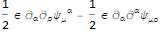

In [51]:
eq /. einsteinGauge

-(ϵ BD[uα, BD[lα, ψ[lμ, lρ]]])
------------------------------
              2
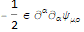

In [52]:
% /. BD[a_, BD[b_, expr_]] :> BD[b, BD[a, expr]] /. einsteinGauge

The gauge is not completely fixed because we can always carry out additional transformations with $\partial^2 \xi^\mu = 0$, which leaves the Einstein gauge unaltered.

Calculating $\eta^{\mu\nu} \partial^2 \psi_{\mu\nu}$ we see that $(1 - \text{dimension}/2) \partial^2 h$.

h[lσ, uσ] η[lμ, lν]
h[lμ, lν] - -------------------
                     2
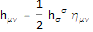

In [53]:
h[l\[Mu], l\[Nu]] - 1/2 \[Eta][l\[Mu], l\[Nu]] h[l\[Sigma], u\[Sigma]]

BD[lρ, η[lμ, lν]] BD[uρ, h[lσ, uσ]] η[uμ, uν]
BD[lρ, BD[uρ, h[lμ, lν]]] η[uμ, uν] - --------------------------------------------- - 
                                                            2
 
    BD[lρ, h[lσ, uσ]] BD[uρ, η[lμ, lν]] η[uμ, uν]
>   --------------------------------------------- - 
                          2
 
    BD[lρ, BD[uρ, η[lμ, lν]]] h[lσ, uσ] η[uμ, uν]
>   --------------------------------------------- - 
                          2
 
    BD[lρ, BD[uρ, h[lσ, uσ]]] η[lμ, lν] η[uμ, uν]
>   ---------------------------------------------
                          2
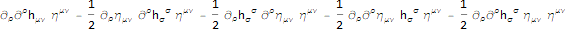

In [54]:
\[Eta][u\[Mu], u\[Nu]] BD[l\[Rho], BD[u\[Rho], %]]

BD[lρ, BD[uρ, h[lσ, uσ]]] η[uμ, lμ]
BD[lρ, BD[uρ, h[lμ, uμ]]] - -----------------------------------
                                             2
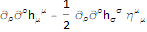

In [55]:
Absorb[%, \[Eta], CovDs -> {BD}] /. etaRule

Therefore, in vacuum, the Einstein equation $\partial^2 \psi_{\mu\nu} = 0$ becomes $\partial^2 h_{\mu\nu} = 0$ in the Einstein gauge $\partial_\mu \psi^\mu_{\ \ \nu} = \partial_\mu h_\nu^{\ \ \mu} - \frac{1}{2} \partial_\nu h = 0$.

-(ϵ BD[lμ, BD[lρ, h[lν, lσ]]])   ϵ BD[lμ, BD[lσ, h[lν, lρ]]]
------------------------------ + --------------------------- + 
              2                               2
 
    ϵ BD[lν, BD[lρ, h[lμ, lσ]]]   ϵ BD[lν, BD[lσ, h[lμ, lρ]]]
>   --------------------------- - ---------------------------
                 2                             2
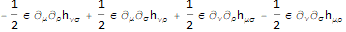

In [56]:
RiemannCD[l\[Mu], l\[Nu], l\[Rho], l\[Sigma]] /. curvRule

The vacuum Einstein equation implies $\partial^2 R_{\mu\nu\rho\sigma} = 0$ which obeys the wave equation. This means that, in the linealized theory, gravitational effects propagate with the light velocity.